# Limpieza y Análisis Exploratorio de Datos
### Proyecto: Segmentación de Clientes en Centros Comerciales
**Materia:** Ciencia de Datos I  
**Institución:** ETITC  
**Autores:** Daniel Valencia, Daniel Medcalfe  
**Dataset:** Customer Shopping Dataset - Istanbul, Kaggle (2021–2023)

## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')


def get_project_root():
    path = Path.cwd().resolve()
    while path != path.parent:
        if (path / 'data').exists() and (path / 'reports').exists():
            return path
        path = path.parent
    return path


## 2. Cargar el dataset

In [2]:
df = pd.read_csv(r"c:\Users\Usuario\OneDrive - Escuela Tecnologica Instituto Tecnico Central\Documentos\ETITC\Ciencia de datos\segmentacion_de_clientes\data\raw\customer_shopping_data.csv")

print("Filas y columnas:", df.shape)
print("\nPrimeras filas:")
df.head()

Filas y columnas: (99457, 10)

Primeras filas:


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


## 3. Revisión inicial

In [3]:
print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

Tipos de datos:
invoice_no            str
customer_id           str
gender                str
age                 int64
category              str
quantity            int64
price             float64
payment_method        str
invoice_date          str
shopping_mall         str
dtype: object

Valores nulos:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

Filas duplicadas: 0


## 4. Limpieza de datos

In [4]:
# Convertir fecha a tipo datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)

# Crear columnas útiles
df['total_spend'] = df['price'] * df['quantity']
df['year']  = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month

# Convertir categorías
for col in ['gender', 'category', 'payment_method', 'shopping_mall']:
    df[col] = df[col].astype('category')

print("Dataset limpio:", df.shape)
print("\nNuevos tipos:")
print(df.dtypes)

Dataset limpio: (99457, 13)

Nuevos tipos:
invoice_no                   str
customer_id                  str
gender                  category
age                        int64
category                category
quantity                   int64
price                    float64
payment_method          category
invoice_date      datetime64[us]
shopping_mall           category
total_spend              float64
year                       int32
month                      int32
dtype: object


## 5. Estadísticas descriptivas

In [5]:
df[['age', 'quantity', 'price', 'total_spend']].describe().round(2)

,age,quantity,price,total_spend
count,99457.00,99457.00,99457.00,99457.00
mean,43.43,3.00,689.26,2528.79
std,14.99,1.41,941.18,4222.48
min,18.00,1.00,5.23,5.23
25%,30.00,2.00,45.45,136.35
50%,43.00,3.00,203.30,600.17
75%,56.00,4.00,1200.32,2700.72
max,69.00,5.00,5250.00,26250.00


## 6. Distribución de edad y gasto

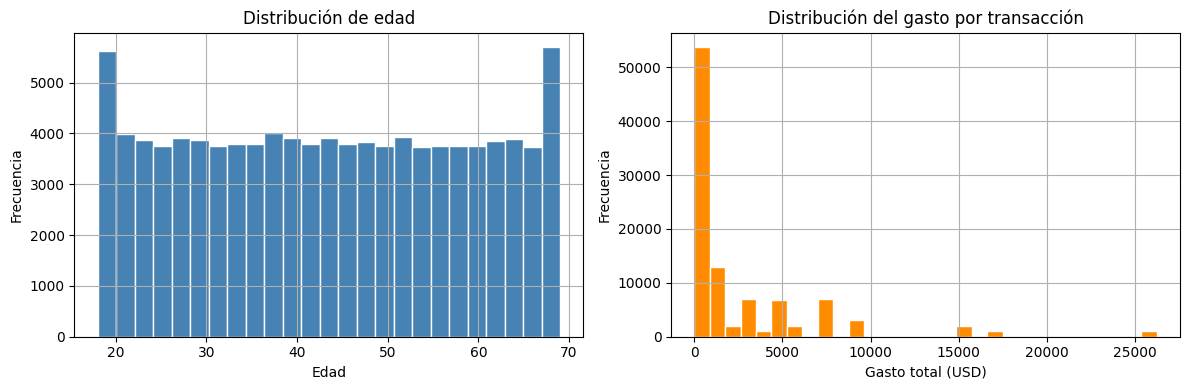

In [6]:
from pathlib import Path

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['age'].hist(bins=25, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

df['total_spend'].hist(bins=30, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Distribución del gasto por transacción')
axes[1].set_xlabel('Gasto total (USD)')
axes[1].set_ylabel('Frecuencia')

project_root = get_project_root()
output_path = project_root / 'reports' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(output_path / 'dist_edad_gasto.png')
plt.show()

## 7. Ingresos por categoría

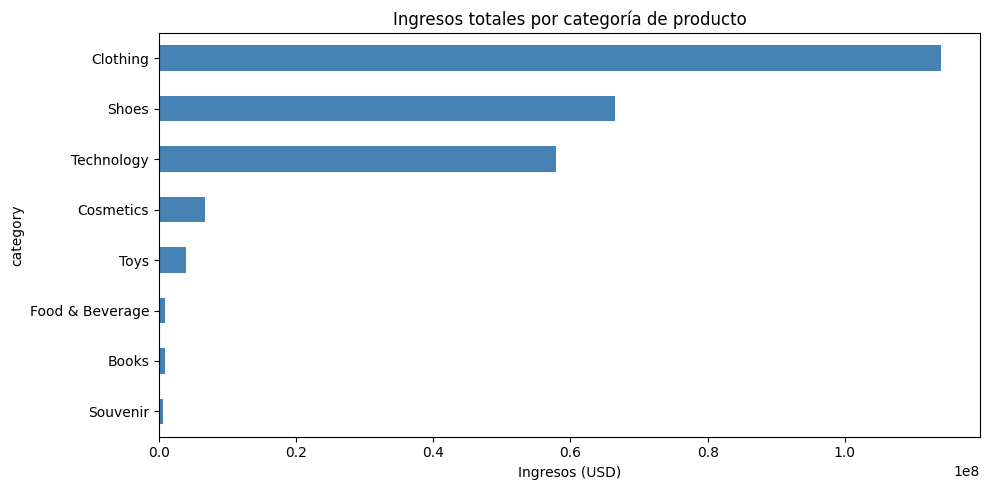

category
Clothing           1.139968e+08
Shoes              6.655345e+07
Technology         5.786235e+07
Cosmetics          6.792863e+06
Toys               3.980426e+06
Food & Beverage    8.495351e+05
Books              8.345529e+05
Souvenir           6.358247e+05
Name: total_spend, dtype: float64


In [7]:
ingresos = df.groupby('category', observed=True)['total_spend'].sum().sort_values()

project_root = get_project_root()
output_path = project_root / 'reports' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
ingresos.plot(kind='barh', color='steelblue')
plt.title('Ingresos totales por categoría de producto')
plt.xlabel('Ingresos (USD)')
plt.tight_layout()
plt.savefig(output_path / 'ingresos_categoria.png')
plt.show()

print(ingresos.sort_values(ascending=False))

## 8. Distribución por género

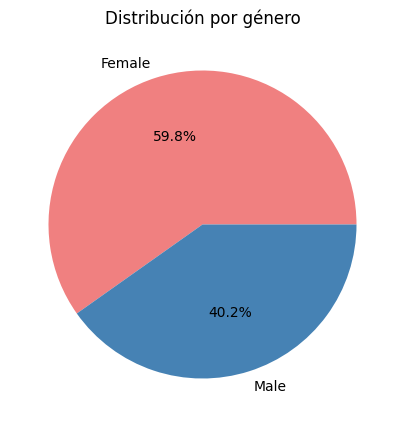

In [8]:
genero = df['gender'].value_counts()

project_root = get_project_root()
output_path = project_root / 'reports' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(5, 5))
plt.pie(genero.values, labels=genero.index, autopct='%1.1f%%',
        colors=['lightcoral', 'steelblue'])
plt.title('Distribución por género')
plt.savefig(output_path / 'genero.png')
plt.show()

## 9. Métodos de pago

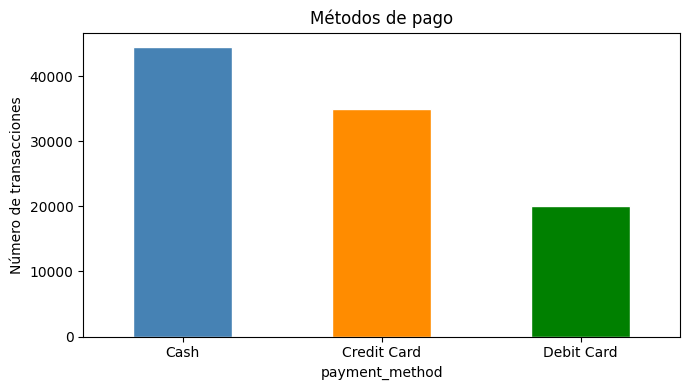

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64


In [9]:
pago = df['payment_method'].value_counts()

project_root = get_project_root()
output_path = project_root / 'reports' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4))
pago.plot(kind='bar', color=['steelblue', 'darkorange', 'green'], edgecolor='white')
plt.title('Métodos de pago')
plt.ylabel('Número de transacciones')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_path / 'metodos_pago.png')
plt.show()

print(pago)

## 10. Ingresos por centro comercial

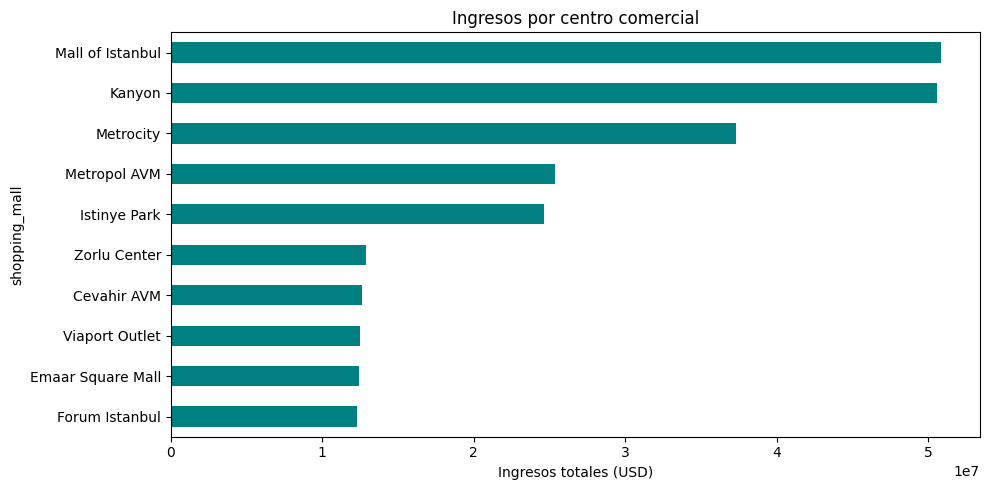

In [10]:
mall = df.groupby('shopping_mall', observed=True)['total_spend'].sum().sort_values()

project_root = get_project_root()
output_path = project_root / 'reports' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
mall.plot(kind='barh', color='teal')
plt.title('Ingresos por centro comercial')
plt.xlabel('Ingresos totales (USD)')
plt.tight_layout()
plt.savefig(output_path / 'ingresos_mall.png')
plt.show()

## 11. Tendencia mensual de ingresos

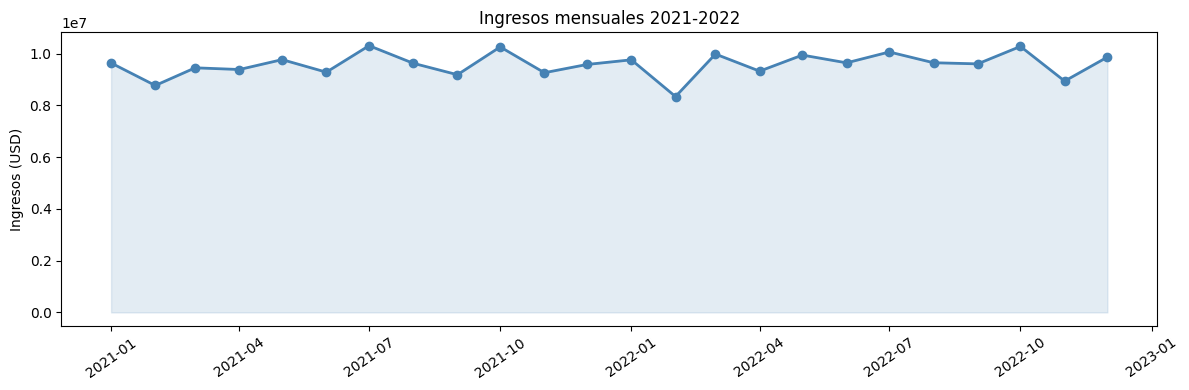

In [11]:
# Solo 2021 y 2022 (2023 tiene datos incompletos)
df_completo = df[df['year'] < 2023]

temporal = df_completo.groupby(['year', 'month'])['total_spend'].sum().reset_index()
temporal['periodo'] = pd.to_datetime(temporal['year'].astype(str) + '-' + temporal['month'].astype(str))

project_root = get_project_root()
output_path = project_root / 'reports' / 'figures'
output_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 4))
plt.plot(temporal['periodo'], temporal['total_spend'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(temporal['periodo'], temporal['total_spend'], alpha=0.15, color='steelblue')
plt.title('Ingresos mensuales 2021-2022')
plt.ylabel('Ingresos (USD)')
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(output_path / 'tendencia_temporal.png')
plt.show()

## 12. Guardar dataset limpio

In [12]:
project_root = get_project_root()
output_file = project_root / 'data' / 'processed' / 'datos_limpios.csv'
output_file.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_file, index=False)
print(f"Dataset guardado en: {output_file.relative_to(project_root)}")
print("Filas:", len(df))
print("Columnas:", df.columns.tolist())

Dataset guardado en: data\processed\datos_limpios.csv
Filas: 99457
Columnas: ['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'invoice_date', 'shopping_mall', 'total_spend', 'year', 'month']
